# Read stats

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [3]:
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")

human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell


In [4]:
paths = [
    "../analysis/downsample_qc/sarek_GRCh38/outdir/multiqc/GA_24_11_scWGS_downsampled_GRCh38_multiqc_report_data/multiqc_samtools_stats.txt",
    "../analysis/downsample_40M/sarek_GRCh38/outdir/multiqc/GA_24_11_scWGS_downsampled_GRCh38_multiqc_report_data/multiqc_samtools_stats.txt",
    "../analysis/qiagen_repli_g_full/sarek/multiqc/GA_24_11_scWGS_Qiagen_Full_GRCh38_multiqc_report_data/multiqc_samtools_stats.txt",
]
reads = ["2M", "40M", "full"]
data = []
for path, r in zip(paths, reads):
    d = pd.read_csv(path, sep="\t")
    
    d["reads"] = r
    d["NGI ID"] = d["Sample"].str.split(".").str[0]
    d = d.drop("Sample", axis=1)
    data.append(d)

data = pd.concat(data)
data = data.merge(samples, on="NGI ID")
data["percent_diff_chrom"] = 100 * data["pairs_on_different_chromosomes"] / data["reads_mapped"]
data["percent_wrong_orient"] = 100 * (data["outward_oriented_pairs"] + data["pairs_with_other_orientation"]) / data["reads_mapped"]
data["percent_outward_orient"] = 100 * data["outward_oriented_pairs"] / data["reads_mapped"]
data["percent_other_orient"] = 100 * data["pairs_with_other_orientation"] / data["reads_mapped"]
data["percent_supplementary_alignments"] = 100 * data["supplementary_alignments"] / data["reads_mapped"]
data["chimera"] = data["pairs_on_different_chromosomes"] + data["pairs_with_other_orientation"] + data["outward_oriented_pairs"] + data["supplementary_alignments"]
data["percent_chimera"] = 100 * data["chimera"] / data["reads_mapped"]
data.head()

,raw_total_sequences,filtered_sequences,sequences,is_sorted,1st_fragments,last_fragments,reads_mapped,reads_mapped_and_paired,reads_unmapped,reads_properly_paired,...,Genome,SampleName,Type,percent_diff_chrom,percent_wrong_orient,percent_outward_orient,percent_other_orient,percent_supplementary_alignments,chimera,percent_chimera
0,3935996.0,0.0,3935996.0,1.0,1967998.0,1967998.0,3935280.0,3935024.0,716.0,3802540.0,...,Human,Qiagen (Cell#01),Single cell,0.456969,7.235927,6.319525,0.916402,2.869554,415662.0,10.562450
1,3946922.0,0.0,3946922.0,1.0,1973461.0,1973461.0,3946317.0,3946104.0,605.0,3810594.0,...,Human,Qiagen (Cell#02),Single cell,0.423610,7.467190,6.494511,0.972679,2.999683,429773.0,10.890483
2,3951100.0,0.0,3951100.0,1.0,1975550.0,1975550.0,3950471.0,3950194.0,629.0,3814704.0,...,Human,Qiagen (Cell#03),Single cell,0.428734,7.798868,6.842830,0.956038,3.059610,445898.0,11.287211
3,3947860.0,0.0,3947860.0,1.0,1973930.0,1973930.0,3947165.0,3946892.0,695.0,3810766.0,...,Human,Qiagen (Cell#04),Single cell,0.430638,7.948490,6.988053,0.960436,3.243011,458745.0,11.622139
4,3950382.0,0.0,3950382.0,1.0,1975191.0,1975191.0,3949639.0,3949390.0,743.0,3815156.0,...,Human,Qiagen (Cell#05),Single cell,0.417456,7.715490,6.763251,0.952239,3.071471,442534.0,11.204416


In [53]:
data.query("reads == '40M'")[["insert_size_average", "insert_size_standard_deviation", "SampleName", "reads"]]

,insert_size_average,insert_size_standard_deviation,SampleName,reads
22,219.6,102.1,Qiagen (Cell#01),40M
23,220.6,105.3,Qiagen (Cell#02),40M
24,217.5,105.0,Qiagen (Cell#03),40M
25,214.6,102.5,Qiagen (Cell#04),40M
26,217.3,103.7,Qiagen (Cell#05),40M
27,214.8,102.0,Qiagen (Cell#06),40M
28,215.7,102.0,Qiagen (Cell#07),40M
29,218.6,102.0,Qiagen (Cell#08),40M
30,220.7,106.1,Qiagen (Cell#09),40M
31,215.9,104.6,Qiagen (Cell#10),40M


In [5]:
data.query("reads == '2M'").set_index("NGI ID")[["percent_diff_chrom", "percent_other_orient", "percent_supplementary_alignments"]].to_clipboard()

/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_61995/3969688002.py:17: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


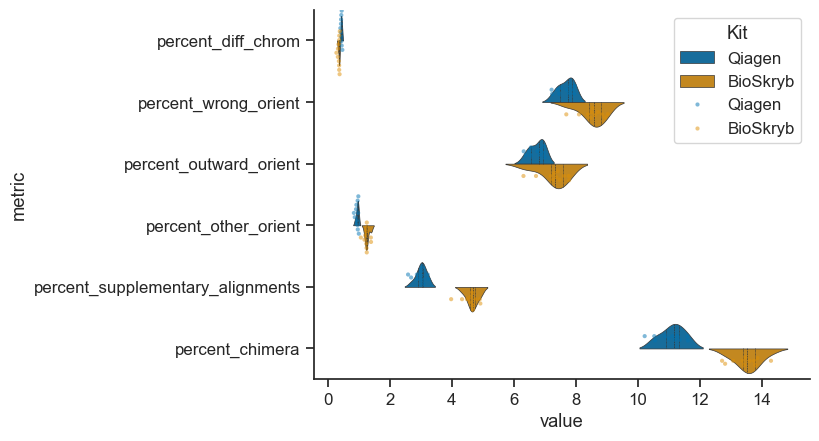

In [6]:
d = data[data["reads"] == "2M"]

d = d.melt(
    id_vars=["NGI ID", "Type", "Kit"],
    value_vars=[
        "percent_diff_chrom",
        "percent_wrong_orient",
        "percent_outward_orient",
        "percent_other_orient",
        "percent_supplementary_alignments",
        "percent_chimera",
    ],
    var_name="metric",
    value_name="value"
)

ax = sns.violinplot(
    data=d.query("Type == 'Single cell'"),
    y="metric",
    x="value",
    hue="Kit",
    split=True,
    inner="quartile",
    scale="width",
    linewidth=0.5,
)
ax = sns.swarmplot(
    data=d,
    y="metric",
    x="value",
    hue="Kit",
    dodge=True,
    alpha=0.5,
    size=3,
    palette="colorblind"
)

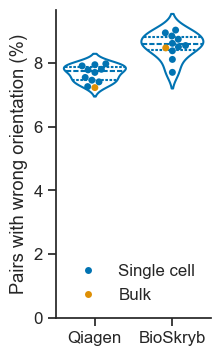

In [7]:
d = data[data["reads"] == "40M"]
fig, ax = plt.subplots(figsize=(2, 4))
ax = sns.violinplot(
    data=d.query("Type == 'Single cell'"), 
    x="Kit", 
    y="percent_wrong_orient", 
    inner="quart", 
    fill=None, 
    density_norm="width", 
    ax=ax
)
ax = sns.swarmplot(
    data=d, 
    x="Kit", 
    y="percent_wrong_orient", 
    hue="Type", 
    ax=ax
)
ax.set_ylim(bottom=0)
ax.set_ylabel("Pairs with wrong orientation (%)")
ax.set_xlabel("")
plt.legend(frameon=False, framealpha=0)
plt.savefig(figdir / "discordant_wrong_orient.svg", bbox_inches="tight")

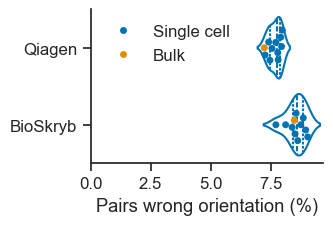

In [8]:
d = data[data["reads"] == "40M"]
fig, ax = plt.subplots(figsize=(3, 2))
ax = sns.violinplot(
    data=d.query("Type == 'Single cell'"), 
    y="Kit", 
    x="percent_wrong_orient", 
    inner="quart", 
    density_norm="width", 
    fill=None, 
    ax=ax
)
ax = sns.swarmplot(
    data=d, 
    y="Kit", 
    x="percent_wrong_orient", 
    hue="Type", 
    ax=ax)
ax.set_xlim(left=0)
ax.set_xlabel("Pairs wrong orientation (%)")
ax.set_ylabel("")
plt.legend(frameon=False, framealpha=0)
plt.savefig(figdir / "discordant_wrong_orient_h.svg", bbox_inches="tight")

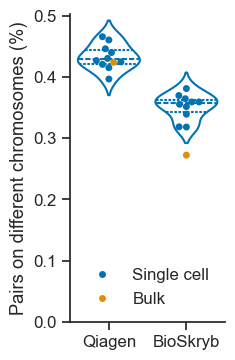

In [9]:
d = data[data["reads"] == "40M"]
fig, ax = plt.subplots(figsize=(2, 4))
ax = sns.violinplot(
    data=d.query("Type == 'Single cell'"),
    density_norm="width", 
    x="Kit", y="percent_diff_chrom", inner="quart", fill=None, ax=ax
)
ax = sns.swarmplot(
    data=d,
    x="Kit", y="percent_diff_chrom", hue="Type", ax=ax
)
ax.set_ylim(bottom=0)
ax.set_ylabel("Pairs on different chromosomes (%)")
ax.set_xlabel("")
plt.legend(frameon=False, framealpha=0)
plt.savefig(figdir / "discordant_translocations.svg", bbox_inches="tight")

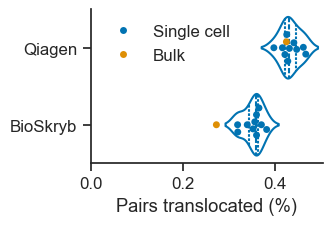

In [10]:
d = data[data["reads"] == "40M"]
fig, ax = plt.subplots(figsize=(3, 2))
ax = sns.violinplot(
    data=d.query("Type == 'Single cell'"),
    density_norm="width", 
    y="Kit", x="percent_diff_chrom", inner="quart", fill=None, ax=ax
)
ax = sns.swarmplot(data=d, y="Kit", x="percent_diff_chrom", hue="Type", ax=ax)
ax.set_xlim(left=0)
ax.set_xlabel("Pairs translocated (%)")
ax.set_ylabel("")
plt.legend(frameon=False, framealpha=0)
plt.savefig(figdir / "discordant_translocations_h.svg", bbox_inches="tight")

<Axes: xlabel='Kit', ylabel='reads_mapped_and_paired_percent'>

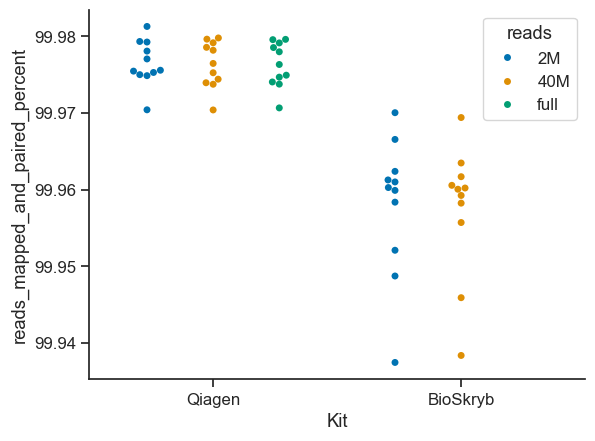

In [11]:
sns.swarmplot(data=data, x="Kit", y="reads_mapped_and_paired_percent", hue="reads", dodge=True)

<Axes: xlabel='Kit', ylabel='reads_MQ0_percent'>

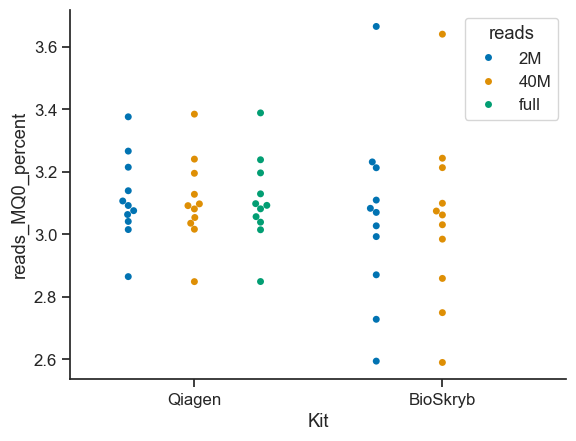

In [12]:
sns.swarmplot(data=data, x="Kit", y="reads_MQ0_percent", hue="reads", dodge=True)

<Axes: xlabel='Kit', ylabel='error_rate'>

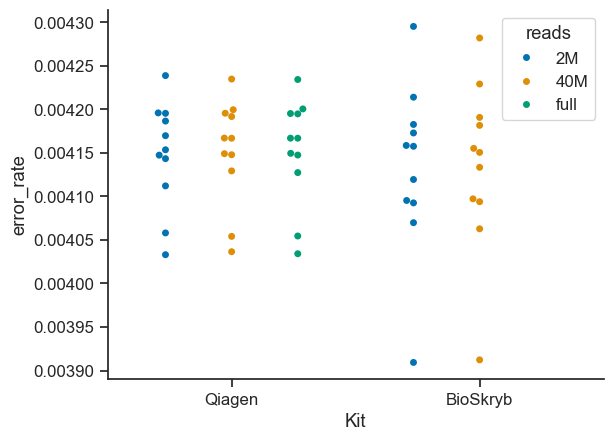

In [13]:
sns.swarmplot(data=data, x="Kit", y="error_rate", hue="reads", dodge=True)

## Insert size

In [46]:
paths = [
    "../analysis/downsample_40M/sarek_GRCh38/outdir/multiqc/GA_24_11_scWGS_downsampled_GRCh38_multiqc_report_data/multiqc_samtools_stats.txt",
    "../analysis/qiagen_repli_g_full/sarek/multiqc/GA_24_11_scWGS_Qiagen_Full_GRCh38_multiqc_report_data/multiqc_samtools_stats.txt",
]
reads = ["2M", "40M", "full"]
lens = []
for file in Path("../analysis/downsample_40M/sarek_GRCh38/outdir/reports/samtools/").rglob("*.stats"):
    d = []
    with open(file, "r") as f:
        for line in f:
            if not line.startswith("IS"):
                continue

            # Columns are insert size, pairs total, inward oriented pairs, outward oriented pairs, other pairs
            tag, insert_size, pairs_total, inward_oriented_pairs, outward_oriented_pairs, other_pairs = line.strip().split("\t")

            d.append(
                {
                    "insert_size": int(insert_size),
                    "pairs_total": int(pairs_total),
                    "inward_oriented_pairs": int(inward_oriented_pairs),
                    "outward_oriented_pairs": int(outward_oriented_pairs),
                    "other_pairs": int(other_pairs)
                }
            )
    d = pd.DataFrame(d)
    d["NGI ID"] = file.stem.split(".")[0]
    d["pct_of_pairs"] = d["pairs_total"] / d["pairs_total"].sum()
    d["cumulative_pairs"] = 1 - d["pct_of_pairs"].cumsum()
    d["pct_of_outward_oriented_pairs"] = d["outward_oriented_pairs"] / d["pairs_total"]
    d["pct_of_inward_oriented_pairs"] = d["inward_oriented_pairs"] / d["pairs_total"]
    d["pct_of_other_pairs"] = d["other_pairs"] / d["pairs_total"]
    d["cumulative_outward_oriented_pairs"] = 1 - d["pct_of_outward_oriented_pairs"].cumsum()
    d["cumulative_inward_oriented_pairs"] = 1 - d["pct_of_inward_oriented_pairs"].cumsum()
    d["cumulative_other_pairs"] = 1 - d["pct_of_other_pairs"].cumsum()
    lens.append(d)


lens = pd.concat(lens)
lens = lens.merge(samples, on="NGI ID")
lens

,insert_size,pairs_total,inward_oriented_pairs,outward_oriented_pairs,other_pairs,NGI ID,pct_of_pairs,cumulative_pairs,pct_of_outward_oriented_pairs,pct_of_inward_oriented_pairs,...,cumulative_outward_oriented_pairs,cumulative_inward_oriented_pairs,cumulative_other_pairs,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,0,153,0,29,124,P33410_1006,0.000004,9.999961e-01,0.189542,0.000000,...,0.810458,1.000000,0.189542,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
1,1,0,0,0,0,P33410_1006,0.000000,9.999961e-01,NaN,NaN,...,NaN,NaN,NaN,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
2,2,160,0,95,65,P33410_1006,0.000004,9.999919e-01,0.593750,0.000000,...,0.216708,1.000000,-0.216708,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
3,3,150,0,79,71,P33410_1006,0.000004,9.999881e-01,0.526667,0.000000,...,-0.309959,1.000000,-0.690041,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
4,4,171,0,92,79,P33410_1006,0.000004,9.999837e-01,0.538012,0.000000,...,-0.847971,1.000000,-1.152029,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15464,602,2010,1595,112,303,P33410_1020,0.000052,2.041958e-04,0.055721,0.793532,...,-77.239503,-482.180005,-39.580492,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell
15465,603,2045,1646,88,311,P33410_1020,0.000053,1.514577e-04,0.043032,0.804890,...,-77.282535,-482.984895,-39.732570,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell
15466,604,1953,1536,92,325,P33410_1020,0.000050,1.010921e-04,0.047107,0.786482,...,-77.329642,-483.771377,-39.898981,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell
15467,605,1997,1587,105,305,P33410_1020,0.000052,4.959188e-05,0.052579,0.794692,...,-77.382221,-484.566069,-40.051710,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell


<Axes: xlabel='insert_size', ylabel='cumulative_pairs'>

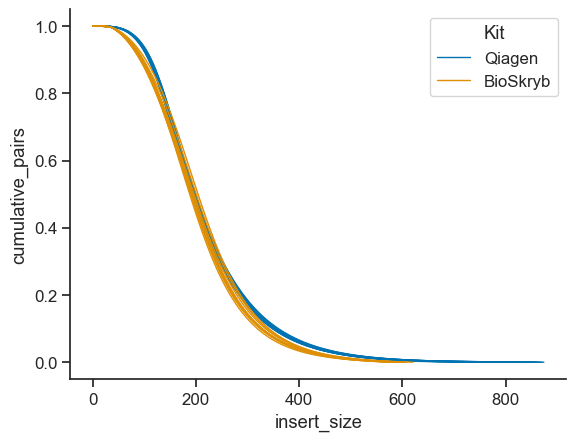

In [15]:
sns.lineplot(
    data=lens, #.query("Type == 'Single cell'"),
    x="insert_size",
    y="cumulative_pairs",
    hue="Kit",
    palette="colorblind",
    linewidth=1,
    units="NGI ID",
    estimator=None,
)

(0.0, 600.0)

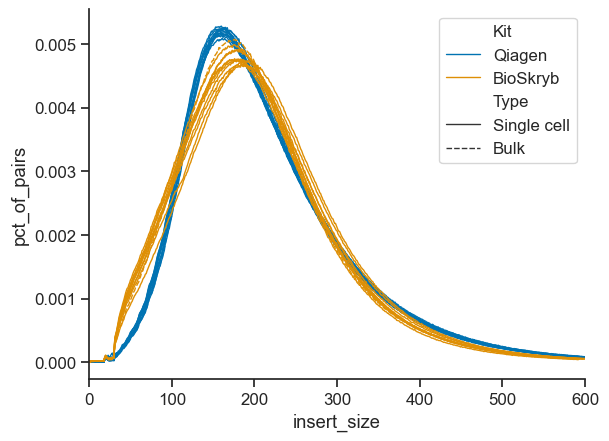

In [26]:
ax = sns.lineplot(
    data=lens, #.query("Type == 'Single cell'"),
    x="insert_size",
    y="pct_of_pairs",
    hue="Kit",
    palette="colorblind",
    style="Type",
    linewidth=1,
    units="NGI ID",
    estimator=None,
)
ax.set_xlim(0, 600)

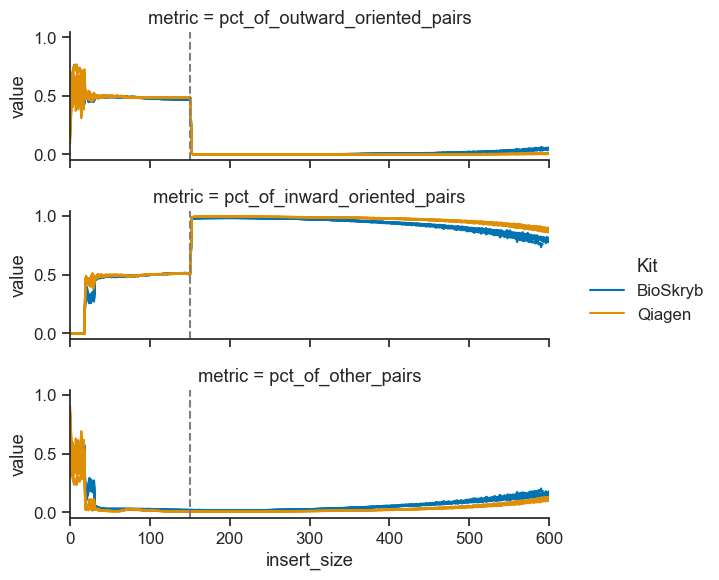

In [51]:
d = lens.melt(
    id_vars=["NGI ID", "Type", "Kit", "insert_size"],
    value_vars=[
        "pct_of_outward_oriented_pairs", 
        "pct_of_inward_oriented_pairs",
        "pct_of_other_pairs",
        #"cumulative_outward_oriented_pairs",
        #"cumulative_inward_oriented_pairs",
        #"cumulative_other_pairs",
        ],
    var_name="metric",
    value_name="value"
)
ids = [
    "P33410_1001",
    "P33410_1002",
    "P33410_1013",
    "P33410_1014",
]
#d["value"] = d.groupby(["NGI ID", "metric"])["value"].transform(lambda x: x / x.max())
g = sns.relplot(
    kind="line",
    row="metric",
    data=d, #.query("`NGI ID` in @ids"),
    x="insert_size",
    y="value",
    hue="Kit",
    hue_order=["BioSkryb", "Qiagen"],
    palette="colorblind",
    units="NGI ID",
    aspect=3,
    height=2,
    estimator=None,
)
g.set(xlim = (0, 600))
g.refline(x=150)

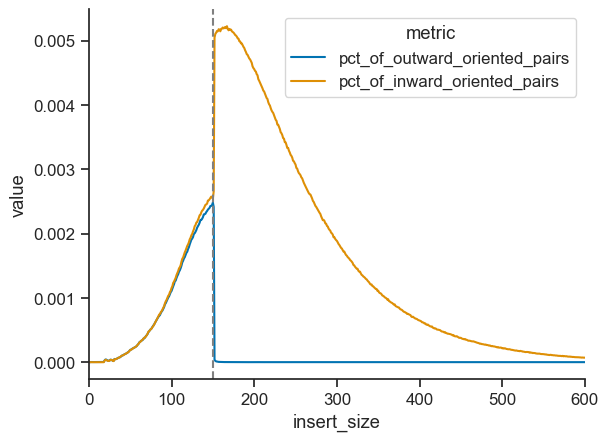

In [18]:
d = lens.melt(
    id_vars=["NGI ID", "Type", "Kit", "insert_size"],
    value_vars=[
        #"pct_of_pairs", 
        "pct_of_outward_oriented_pairs", 
        "pct_of_inward_oriented_pairs",
        #"pct_of_other_pairs",
        #"cumulative_outward_oriented_pairs",
        #"cumulative_inward_oriented_pairs",
        #"cumulative_other_pairs",
        ],
    var_name="metric",
    value_name="value"
)
ids = [
    "P33410_1001",
    # "P33410_1002",
    # "P33410_1013",
    # "P33410_1014",
]
#d["value"] = d.groupby(["NGI ID", "metric"])["value"].transform(lambda x: x / x.max())
ax = sns.lineplot(
    data=d.query("`NGI ID` in @ids"),
    x="insert_size",
    y="value",
    hue="metric",
    palette="colorblind",
    units="NGI ID",
    estimator=None,
)
ax.set_xlim(0, 600)
ax.axvline(150, ls="--", color="gray")

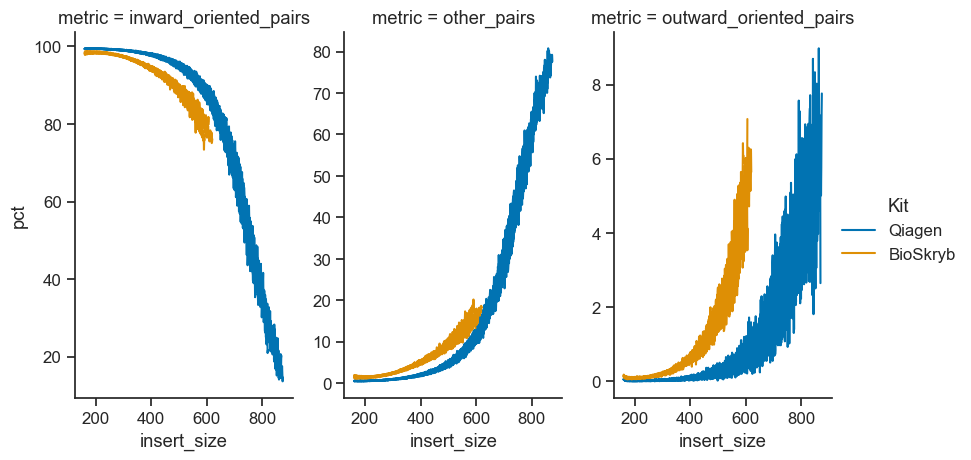

In [19]:
d = lens.query("insert_size > 160")
d = d.melt(
    id_vars=["NGI ID", "Type", "Kit", "insert_size"],
    value_vars=[
        #"pairs_total",
        "outward_oriented_pairs",
        "inward_oriented_pairs",
        "other_pairs",
    ],
    var_name="metric",
    value_name="value"
)
d = d.groupby(["NGI ID", "metric", "Kit", "insert_size"]).agg({"value": "sum"}).reset_index()
d["pct"] = d.groupby(["NGI ID", "insert_size"])["value"].transform(lambda x: 100 * x / x.sum())

sns.relplot(
    data=d,
    x="insert_size",
    col="metric",
    y="pct",
    kind="line",
    units="NGI ID",
    hue="Kit",
    estimator=None,
    height=4.8,
    aspect=0.6,
    facet_kws={"sharey": False},
)

In [20]:
d = lens.query("insert_size > 160").groupby("NGI ID").agg(
    {"outward_oriented_pairs": "sum", "inward_oriented_pairs": "sum", "other_pairs": "sum"})
d = d.apply(lambda x: 100 * x / x.sum(), axis=1)
d = d.drop(columns=["inward_oriented_pairs"])
d["wrong_orient"] = d.sum(axis=1)
d.to_clipboard()

## Chimeric reads (translocations or pair spaced >10000 bp)

In [32]:
chms = pd.read_csv("../analysis/downsample_40M/downstream/chimeric_reads/counts.txt", sep="\t")
chms["pct_chimeric"] = 100 * chms["chimeric_reads"] / chms["all_reads"]
chms["NGI ID"] = chms["sample"]
chms = chms.merge(samples, on="NGI ID")
chms["Kit_Type"] = chms["Kit"] + "_" + chms["Type"]
chms

,sample,all_reads,chimeric_reads,pct_chimeric,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Kit_Type
0,P33410_1001,73461832,423030,0.575850,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,Qiagen_Single cell
1,P33410_1002,73788035,393670,0.533515,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell,Qiagen_Single cell
2,P33410_1003,73804320,399565,0.541384,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell,Qiagen_Single cell
3,P33410_1004,73422111,380224,0.517860,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell,Qiagen_Single cell
4,P33410_1005,73772827,382804,0.518896,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell,Qiagen_Single cell
5,P33410_1006,73520816,353873,0.481324,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell,Qiagen_Single cell
6,P33410_1008,73464590,410433,0.558681,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell,Qiagen_Single cell
7,P33410_1009,73848303,418562,0.566786,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell,Qiagen_Single cell
8,P33410_1010,73534974,439562,0.597759,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell,Qiagen_Single cell
9,P33410_1011,73249354,369926,0.505023,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell,Qiagen_Single cell


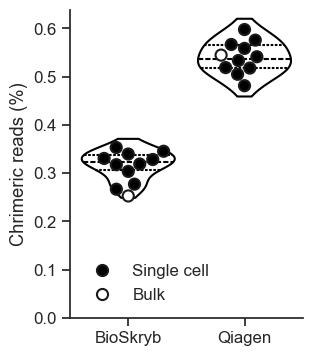

In [52]:
fig, ax = plt.subplots(figsize=(3, 4))
chms = chms.sort_values("Kit")
ax = sns.violinplot(
    data=chms.query("Type == 'Single cell'"), 
    x="Kit", 
    y="pct_chimeric", 
    inner="quart", 
    color="black",
    density_norm="width", 
    cut=1,
    fill=None, 
    zorder=-1,
    ax=ax,
)
ax = sns.swarmplot(
    data=chms, 
    x="Kit", 
    y="pct_chimeric", 
    hue="Type", 
    hue_order=["Single cell", "Bulk"],
    palette=["black", "white"],
    edgecolor="k",
    linewidth=1.5,
    size=8,
    ax=ax)
ax.set_ylim(bottom=0)
ax.set_ylabel("Chrimeric reads (%)")
ax.set_xlabel("")
plt.legend(frameon=False, framealpha=0, loc="lower left")
plt.savefig(figdir / "chimeric_reads.svg", bbox_inches="tight")

In [44]:
chms.groupby(["Kit", "Type"])["pct_chimeric"].mean().round(2)

Kit       Type       
BioSkryb  Bulk           0.25
          Single cell    0.32
Qiagen    Bulk           0.54
          Single cell    0.54
Name: pct_chimeric, dtype: float64

## Chimeric reads (picard AlignmentSummaryMetrics)


In [43]:
chms2 = pd.read_csv("../analysis/downsample_40M/downstream/multiqc_data/multiqc_picard_AlignmentSummaryMetrics.txt", sep="\t")
chms2["NGI ID"] = chms2["Sample"].str.split(".",expand=True)[0]
chms2 = chms2.drop("Sample", axis=1)
chms2 = chms2.merge(samples, on="NGI ID")
chms2

,CATEGORY,TOTAL_READS,PF_READS,PCT_PF_READS,PF_NOISE_READS,PF_READS_ALIGNED,PCT_PF_READS_ALIGNED,PF_ALIGNED_BASES,PF_HQ_ALIGNED_READS,PF_HQ_ALIGNED_BASES,...,LIBRARY,READ_GROUP,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,PAIR,78804164.0,78804164.0,1.0,0.0,78790224.0,0.999823,1.110125e+10,75811970.0,1.071926e+10,...,NaN,NaN,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,PAIR,78996358.0,78996358.0,1.0,0.0,78984878.0,0.999855,1.110700e+10,76086067.0,1.073380e+10,...,NaN,NaN,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell
2,PAIR,79055466.0,79055466.0,1.0,0.0,79043070.0,0.999843,1.106239e+10,76128904.0,1.069090e+10,...,NaN,NaN,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,PAIR,78971364.0,78971364.0,1.0,0.0,78956440.0,0.999811,1.101918e+10,75870742.0,1.063060e+10,...,NaN,NaN,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
4,PAIR,79056198.0,79056198.0,1.0,0.0,79041294.0,0.999811,1.107264e+10,76099054.0,1.070002e+10,...,NaN,NaN,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell
5,PAIR,79008632.0,79008632.0,1.0,0.0,78993361.0,0.999807,1.104296e+10,75897302.0,1.064963e+10,...,NaN,NaN,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
6,PAIR,78793344.0,78793344.0,1.0,0.0,78781586.0,0.999851,1.101576e+10,75821080.0,1.063872e+10,...,NaN,NaN,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell
7,PAIR,78869410.0,78869410.0,1.0,0.0,78857719.0,0.999852,1.109356e+10,76124446.0,1.074175e+10,...,NaN,NaN,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell
8,PAIR,78853772.0,78853772.0,1.0,0.0,78840878.0,0.999836,1.106544e+10,75890638.0,1.068778e+10,...,NaN,NaN,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell
9,PAIR,79005222.0,79005222.0,1.0,0.0,78989254.0,0.999798,1.101161e+10,75734086.0,1.060545e+10,...,NaN,NaN,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell


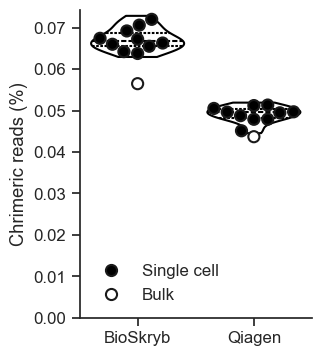

In [45]:
fig, ax = plt.subplots(figsize=(3, 4))
chms2 = chms2.sort_values("Kit")
ax = sns.violinplot(
    data=chms2.query("Type == 'Single cell'"), 
    x="Kit", 
    y="PCT_CHIMERAS", 
    inner="quart", 
    color="black",
    density_norm="width", 
    cut=0.5,
    fill=None, 
    zorder=-1,
    ax=ax,
)
ax = sns.swarmplot(
    data=chms2, 
    x="Kit", 
    y="PCT_CHIMERAS", 
    hue="Type", 
    hue_order=["Single cell", "Bulk"],
    palette=["black", "white"],
    edgecolor="k",
    linewidth=1.5,
    size=8,
    ax=ax)
ax.set_ylim(bottom=0)
ax.set_ylabel("Chrimeric reads (%)")
ax.set_xlabel("")
plt.legend(frameon=False, framealpha=0, loc="lower left")
#plt.savefig(figdir / "chimeric_reads.svg", bbox_inches="tight")

(0.0, 0.07340125)

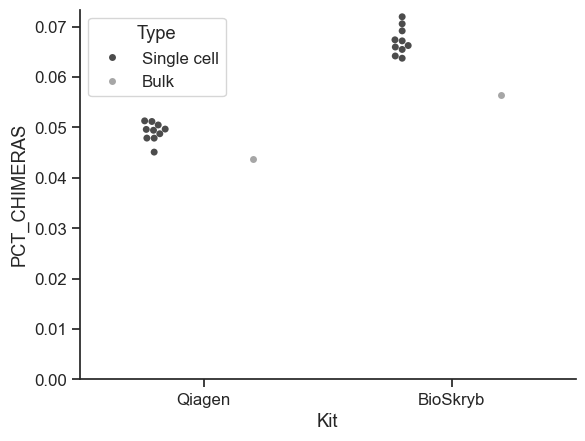

In [162]:
ax = sns.swarmplot(
    data=chms2,
    x="Kit",
    y="PCT_CHIMERAS",
    hue="Type",
    dodge=True,
    palette=["black", "grey"],
    edgecolor="k",
    alpha=0.7,
)
ax.set_ylim(bottom=0)